# Label Attacks

## Label Flipping
Label Flipping is a simple data poisoning attack where an adversary changes the labels of training data points while leaving the features intact, causing the model to learn incorrect associations and degrading overall performance. It targets the integrity of stored datasets and aligns with OWASP LLM03: Training Data Poisoning.

**Our example:** In this example, an attacker flips labels on customer reviews so a sentiment model trained on the poisoned data becomes unreliable and reports the wrong overall sentiment. The company then makes costly wrong decisions (pulling a successful product or “fixing” popular features) based on the corrupted analysis.

### Environment Setup
To demonstrate how such an attack would work, we will build a model around the sentiment analysis scenario. A company is training a model to classify customer feedback as positive or negative, and we, as the adversary, will attack the training dataset by flipping labels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

htb_green = "#9fef00"
node_black = "#141d2b"
hacker_grey = "#a4b1cd"
white = "#ffffff"
azure = "#0086ff"
nugget_yellow = "#ffaf00"
malware_red = "#ff3e3e"
vivid_purple = "#9f00ff"
aquamarine = "#2ee7b6"

# Configure plot styles
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update(
    {
        "figure.facecolor": node_black,
        "axes.facecolor": node_black,
        "axes.edgecolor": hacker_grey,
        "axes.labelcolor": white,
        "text.color": white,
        "xtick.color": hacker_grey,
        "ytick.color": hacker_grey,
        "grid.color": hacker_grey,
        "grid.alpha": 0.1,
        "legend.facecolor": node_black,
        "legend.edgecolor": hacker_grey,
        "legend.frameon": True,
        "legend.framealpha": 1.0,
        "legend.labelcolor": white,
    }
)

# Seed for reproducibility
SEED = 1337
np.random.seed(SEED)

print("Setup complete. Libraries imported and styles configured.")

Setup complete. Libraries imported and styles configured.


### The Dataset
We use Scikit-Learn’s `make_blobs` to generate a simple 2D synthetic dataset of two well-separated clusters that stand in for numerical features extracted from customer reviews. One cluster represents negative sentiment (Class 0) and the other positive (Class 1), making the effect of label flipping easy to visualize on the decision boundary.

In [2]:
# Generate synthetic data
n_samples = 1000
centers = [(0, 5), (5, 0)]  # Define centers for two distinct blobs
X, y = make_blobs(
    n_samples=n_samples,
    centers=centers,
    n_features=2,
    cluster_std=1.25,
    random_state=SEED,
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)

print(f"Generated {n_samples} samples.")
print(f"Training set size: {X_train.shape[0]} samples.")
print(f"Testing set size: {X_test.shape[0]} samples.")
print(f"Number of features: {X_train.shape[1]}")
print(f"Classes: {np.unique(y)}")

Generated 1000 samples.
Training set size: 700 samples.
Testing set size: 300 samples.
Number of features: 2
Classes: [0 1]


### Plot the Dataset

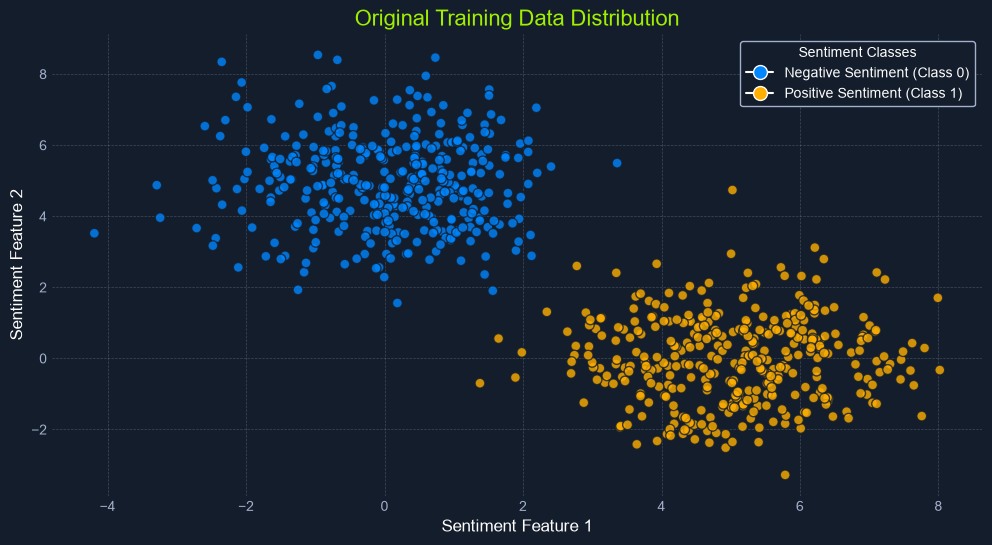

In [3]:
def plot_data(X, y, title="Dataset Visualization"):
    """
    Plots the 2D dataset with class-specific colors.

    Parameters:
    - X (np.ndarray): Feature data (n_samples, 2).
    - y (np.ndarray): Labels (n_samples,).
    - title (str): The title for the plot.
    """
    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
        edgecolors=node_black,
        s=50,
        alpha=0.8,
    )
    plt.title(title, fontsize=16, color=htb_green)
    plt.xlabel("Sentiment Feature 1", fontsize=12)
    plt.ylabel("Sentiment Feature 2", fontsize=12)
    # Create a legend
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Negative Sentiment (Class 0)", 
            markersize=10,
            markerfacecolor=azure,
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Positive Sentiment (Class 1)",
            markersize=10,
            markerfacecolor=nugget_yellow,
        ),
    ]
    plt.legend(handles=handles, title="Sentiment Classes")
    plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.show()


# Plot the data
plot_data(X_train, y_train, title="Original Training Data Distribution")

### Baseline Logistic Regression Model
**Baseline setup:** Train a Logistic Regression classifier on the clean training data (X_train, y_train) to measure normal, non-adversarial performance for later comparison against a poisoned model.

**Model mechanics:** It computes a linear logit z = w^T x + b, converts it to a probability via the sigmoid, and optimizes binary cross-entropy loss to learn weights w and bias b; predictions use a 0.5 threshold, forming a linear decision boundary.

**Next step:** Fit the model on the clean data and report its accuracy on the held-out test set.

Baseline Model Accuracy: 0.9933


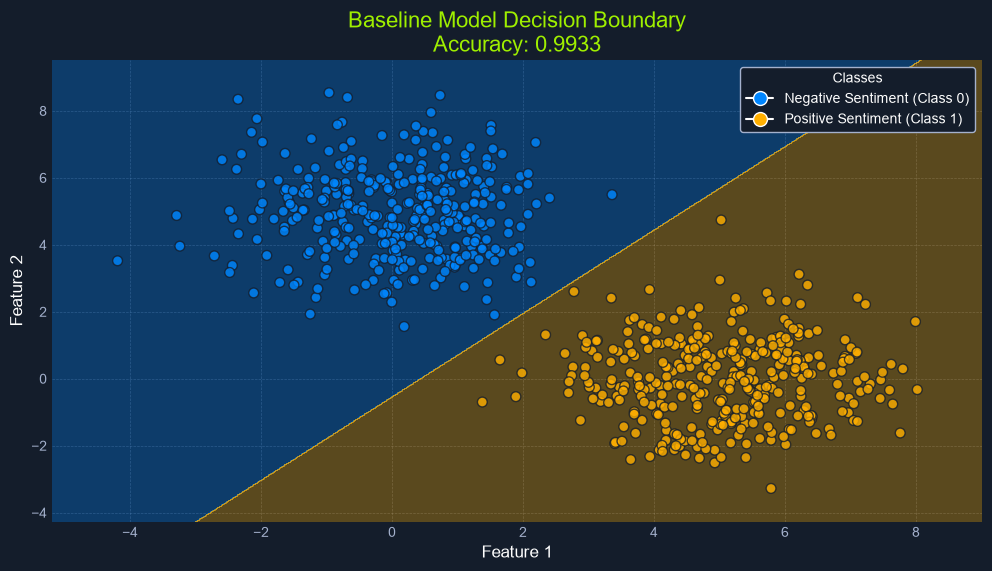

In [4]:
# Initialize and train the Logistic Regression model
baseline_model = LogisticRegression(random_state=SEED)
baseline_model.fit(X_train, y_train)

# Predict on the test set
y_pred_baseline = baseline_model.predict(X_test)

# Calculate baseline accuracy
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Model Accuracy: {baseline_accuracy:.4f}")


# Prepare to plot the decision boundary
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """
    Plots the decision boundary of a trained classifier on a 2D dataset.

    Parameters:
    - model: The trained classifier object (must have a .predict method).
    - X (np.ndarray): Feature data (n_samples, 2).
    - y (np.ndarray): Labels (n_samples,).
    - title (str): The title for the plot.
    """
    h = 0.02  # Step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the class for each point in the mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(12, 6))
    # Plot the decision boundary contour
    plt.contourf(
        xx, yy, Z, cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]), alpha=0.3
    )

    # Plot the data points
    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
        edgecolors=node_black,
        s=50,
        alpha=0.8,
    )

    plt.title(title, fontsize=16, color=htb_green)
    plt.xlabel("Feature 1", fontsize=12)
    plt.ylabel("Feature 2", fontsize=12)

    # Create a legend manually
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Negative Sentiment (Class 0)",
            markersize=10,
            markerfacecolor=azure,
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Positive Sentiment (Class 1)",
            markersize=10,
            markerfacecolor=nugget_yellow,
        ),
    ]
    plt.legend(handles=handles, title="Classes")
    plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()


# Plot the decision boundary for the baseline model
plot_decision_boundary(
    baseline_model,
    X_train,
    y_train,
    title=f"Baseline Model Decision Boundary\nAccuracy: {baseline_accuracy:.4f}",
)

### The Label Flipping Attack
**Attack execution:** Create a function that takes the original y_train labels and a poisoning percentage, then randomly selects that fraction of training points and flips their labels (0↔1).  

**Effect on learning:** Flipped labels corrupt the binary cross-entropy loss terms, forcing the optimizer to adjust w and b to accommodate the poisoned points and thereby shifting the decision boundary (`wᵀx + b = 0`) away from the true data distribution.

Implement a `flip_labels` function that validates a poison percentage (0–1), computes how many labels to flip, and randomly inverts that fraction of the original `y_train` labels.

In [5]:
def flip_labels(y, poison_percentage):
    if not 0 <= poison_percentage <= 1:
        raise ValueError("poison_percentage must be between 0 and 1.")

    n_samples = len(y)
    n_to_flip = int(n_samples * poison_percentage)

    if n_to_flip == 0:
        print("Warning: Poison percentage is 0 or too low to flip any labels.")
        # Return unchanged labels and empty indices if no flips are needed
        return y.copy(), np.array([], dtype=int)
        
    # Using a seeded NumPy RNG, randomly select `n_to_flip` unique indices (without replacement) that identify which training reviews will have their labels flipped.    
    # Use the defined SEED for the random number generator
    rng_instance = np.random.default_rng(SEED)
    # Select unique indices to flip
    flipped_indices = rng_instance.choice(n_samples, size=n_to_flip, replace=False)

    # Create a copy of the labels (y_poisoned = y.copy()), then invert the selected indices with 1 - y_poisoned[flipped_indices] (or np.where) so the original array stays untouched.
    # Create a copy to avoid modifying the original array
    y_poisoned = y.copy()

    # Get the original labels at the indices we are about to flip
    original_labels_at_flipped = y_poisoned[flipped_indices]

    # Apply the flip: if original was 0, set to 1; otherwise (if 1), set to 0
    y_poisoned[flipped_indices] = np.where(original_labels_at_flipped == 0, 1, 0)

    print(f"Flipping {n_to_flip} labels ({poison_percentage * 100:.1f}%).")

    return y_poisoned, flipped_indices
    

### Plot the Corrupted Data

In [6]:
def plot_poisoned_data(
    X,
    y_original,
    y_poisoned,
    flipped_indices,
    title="Poisoned Data Visualization",
    target_class_info=None,
):
    """
    Plots a 2D dataset, highlighting points whose labels were flipped.

    Parameters:
    - X (np.ndarray): Feature data (n_samples, 2).
    - y_original (np.ndarray): The original labels before flipping (used for context if needed, currently unused in logic but good practice).
    - y_poisoned (np.ndarray): Labels after flipping.
    - flipped_indices (np.ndarray): Indices of the samples that were flipped.
    - title (str): The title for the plot.
    - target_class_info (int, optional): The class label of the points that were targeted for flipping. Defaults to None.
    """
    plt.figure(figsize=(12, 7))

    # Identify non-flipped points
    mask_not_flipped = np.ones(len(y_poisoned), dtype=bool)
    mask_not_flipped[flipped_indices] = False

    # Plot non-flipped points (color by their poisoned label, which is same as original)
    plt.scatter(
        X[mask_not_flipped, 0],
        X[mask_not_flipped, 1],
        c=y_poisoned[mask_not_flipped],
        cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
        edgecolors=node_black,
        s=50,
        alpha=0.6,
        label="Unchanged Label",  # Keep this generic
    )

    # Determine the label for flipped points in the legend
    if target_class_info is not None:
        flipped_legend_label = f"Flipped (Orig Class {target_class_info})"
        # You could potentially use target_class_info to adjust facecolor if needed,
        # but current logic colors by the new label which is often clearer.
    else:
        flipped_legend_label = "Flipped Label"

    # Plot flipped points with a distinct marker and outline
    if len(flipped_indices) > 0:
        # Color flipped points according to their new (poisoned) label
        plt.scatter(
            X[flipped_indices, 0],
            X[flipped_indices, 1],
            c=y_poisoned[flipped_indices],  # Color by the new label
            cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
            edgecolors=malware_red,  # Highlight edge in red
            linewidths=1.5,
            marker="X",  # Use 'X' marker
            s=100,
            alpha=0.9,
            label=flipped_legend_label,  # Use the determined label
        )

    plt.title(title, fontsize=16, color=htb_green)
    plt.xlabel("Feature 1", fontsize=12)
    plt.ylabel("Feature 2", fontsize=12)

    # Create legend
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Class 0 Point (Azure)",
            markersize=10,
            markerfacecolor=azure,
            linestyle="None",
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Class 1 Point (Yellow)",
            markersize=10,
            markerfacecolor=nugget_yellow,
            linestyle="None",
        ),
        # Add the flipped legend entry using the label
        plt.Line2D(
            [0],
            [0],
            marker="X",
            color="w",
            label=flipped_legend_label,
            markersize=12,
            markeredgecolor=malware_red,
            markerfacecolor=hacker_grey,
            linestyle="None",
        ),
    ]
    plt.legend(handles=handles, title="Data Points")
    plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.show()

### Evaluating the Label Flipping Attacks
To evaluate a label-flipping attack, 10% of the training labels are randomly flipped, a Logistic Regression model is trained on the poisoned labels with original features, and its accuracy is measured on the clean test set. The corrupted data points and the resulting decision boundary are then visualized to assess the attack’s impact.


--- Testing with 10% Poisoned Data ---
Flipping 70 labels (10.0%).


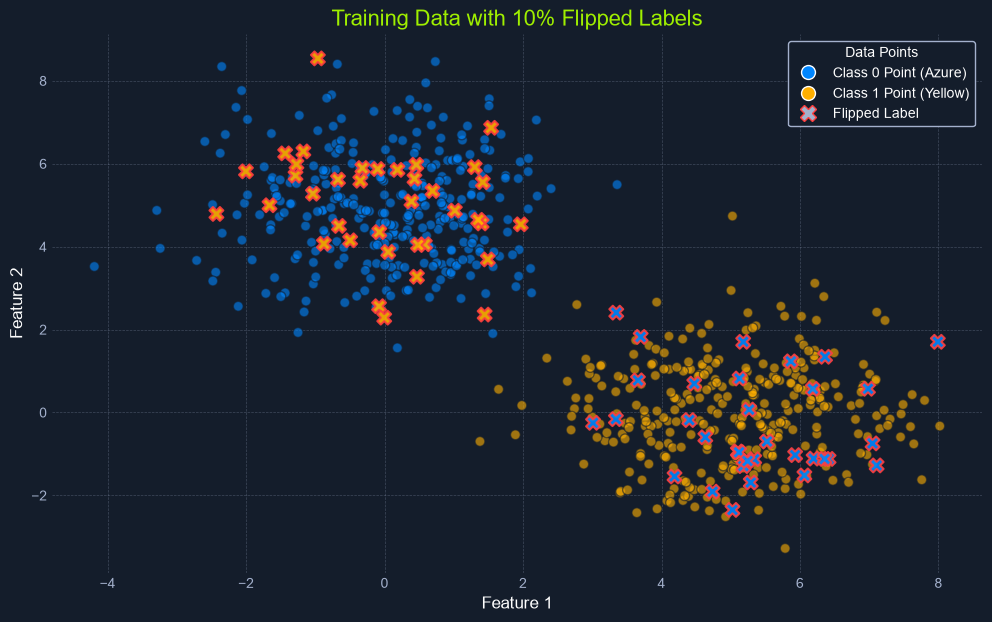

Accuracy on clean test set (10% poisoned): 0.9933


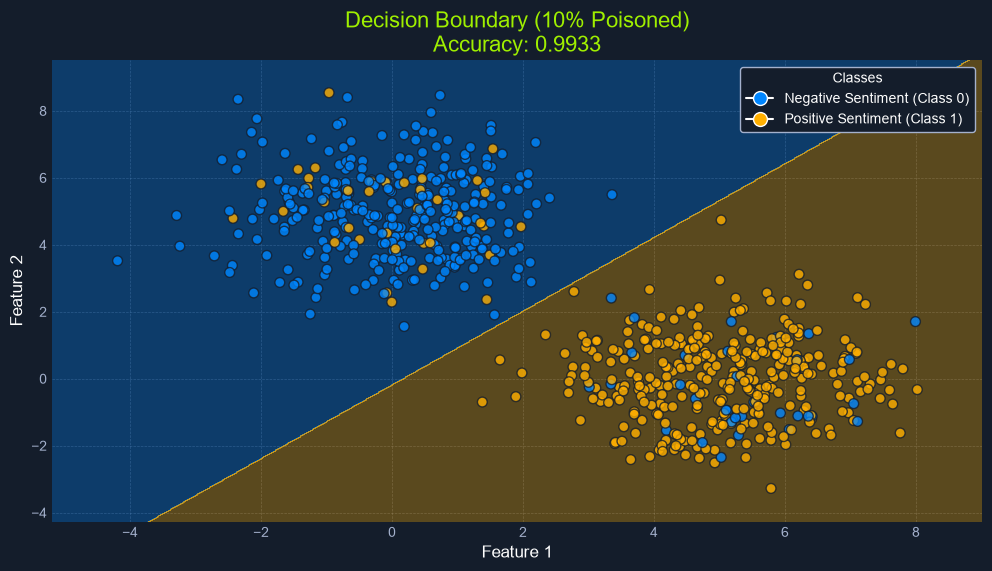

Baseline accuracy was: 0.9933


In [7]:
results = {
    "percentage": [],
    "accuracy": [],
    "model": [],
    "y_train_poisoned": [],
    "flipped_indices": [],
}
decision_boundaries_data = []  # To store data for the combined plot

# Add baseline results first
results["percentage"].append(0.0)
results["accuracy"].append(baseline_accuracy)
results["model"].append(baseline_model)
results["y_train_poisoned"].append(y_train.copy())
results["flipped_indices"].append(np.array([], dtype=int))

# Calculate meshgrid once for all boundary plots
h = 0.02  # Step size in the mesh
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
mesh_points = np.c_[xx.ravel(), yy.ravel()]

# Perform 10% Poisoning
poison_percentage_10 = 0.10
print(f"\n--- Testing with {poison_percentage_10 * 100:.0f}% Poisoned Data ---")

# Create 10% Poisoned Data
y_train_poisoned_10, flipped_indices_10 = flip_labels(y_train, poison_percentage_10)

# Visualize 10% Poisoned Data
plot_poisoned_data(
    X_train,
    y_train,
    y_train_poisoned_10,
    flipped_indices_10,
    title=f"Training Data with {poison_percentage_10 * 100:.0f}% Flipped Labels",
)

# Train Model on 10% Poisoned Data
model_10_percent = LogisticRegression(random_state=SEED)
model_10_percent.fit(X_train, y_train_poisoned_10)  # Train with original X, poisoned y

# Evaluate on Clean Test Data
y_pred_10_percent = model_10_percent.predict(X_test)
accuracy_10_percent = accuracy_score(y_test, y_pred_10_percent)
print(f"Accuracy on clean test set (10% poisoned): {accuracy_10_percent:.4f}")

# Store Results
results["percentage"].append(poison_percentage_10)
results["accuracy"].append(accuracy_10_percent)
results["model"].append(model_10_percent)
results["y_train_poisoned"].append(y_train_poisoned_10)
results["flipped_indices"].append(flipped_indices_10)

# Visualize Decision Boundary
plot_decision_boundary(
    model_10_percent,
    X_train,
    y_train_poisoned_10,  # Visualize boundary with poisoned labels shown
    title=f"Decision Boundary ({poison_percentage_10 * 100:.0f}% Poisoned)\nAccuracy: {accuracy_10_percent:.4f}",
)

# Store decision boundary prediction for combined plot
Z_10 = model_10_percent.predict(mesh_points)
Z_10 = Z_10.reshape(xx.shape)
decision_boundaries_data.append({"percentage": poison_percentage_10, "Z": Z_10})
print(
    f"Baseline accuracy was: {baseline_accuracy:.4f}"
)  # Print baseline for comparison


#### Overlay Poisoned Data
With clearly separated synthetic data, poisoning just 10% of labels leaves test accuracy unchanged at 99.33%, though the decision boundary shifts slightly as the model adapts to the poisoned points. To get a clearer view of the shift, let's overlay the original baseline boundary (trained on clean data) and the 10% poisoned boundary on the same plot.

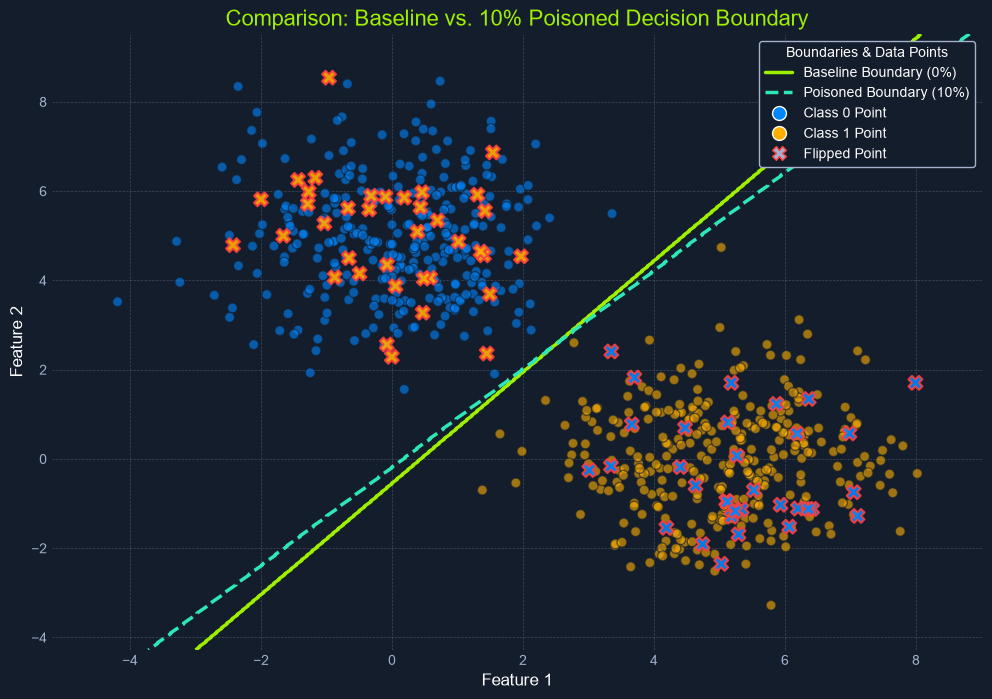

In [8]:
plt.figure(figsize=(12, 8))

# Plot the 10% poisoned data points for context
mask_not_flipped_10 = np.ones(len(y_train), dtype=bool)
mask_not_flipped_10[flipped_indices_10] = False
plt.scatter(
    X_train[mask_not_flipped_10, 0],
    X_train[mask_not_flipped_10, 1],
    c=y_train_poisoned_10[mask_not_flipped_10],
    cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
    edgecolors=node_black,
    s=50,
    alpha=0.6,
    label="Original Label (in 10% set)",
)

# Plot flipped points ('X' marker)
if len(flipped_indices_10) > 0:
    plt.scatter(
        X_train[flipped_indices_10, 0],
        X_train[flipped_indices_10, 1],
        c=y_train_poisoned_10[flipped_indices_10],  # Color by the new poisoned label
        cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
        edgecolors=malware_red,
        linewidths=1.5,
        marker="X",
        s=100,
        alpha=0.9,
        label="Flipped Label (10% set)",
    )

# Overlay Baseline Decision Boundary (Solid Green)
baseline_model_retrieved = results["model"][
    results["percentage"].index(0.0)
]  # Get baseline model
if baseline_model_retrieved:
    Z_baseline = baseline_model_retrieved.predict(mesh_points).reshape(xx.shape)
    plt.contour(
        xx,
        yy,
        Z_baseline,
        levels=[0.5],
        colors=[htb_green],
        linestyles=["solid"],
        linewidths=[2.5],
    )
else:
    print("Warning: Baseline model not found for comparison plot.")


# Overlay 10% Poisoned Decision Boundary
plt.contour(
    xx,
    yy,
    Z_10,
    levels=[0.5],
    colors=[aquamarine],
    linestyles=["dashed"],
    linewidths=[2.5],
)


plt.title(
    "Comparison: Baseline vs. 10% Poisoned Decision Boundary",
    fontsize=16,
    color=htb_green,
)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)

# Create legend
handles = [
    plt.Line2D(
        [0],
        [0],
        color=htb_green,
        lw=2.5,
        linestyle="solid",
        label="Baseline Boundary (0%)",
    ),
    plt.Line2D(
        [0],
        [0],
        color=aquamarine,
        lw=2.5,
        linestyle="dashed",
        label="Poisoned Boundary (10%)",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Class 0 Point",
        markersize=10,
        markerfacecolor=azure,
        linestyle="None",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Class 1 Point",
        markersize=10,
        markerfacecolor=nugget_yellow,
        linestyle="None",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="X",
        color="w",
        label="Flipped Point",
        markersize=10,
        markeredgecolor=malware_red,
        markerfacecolor=hacker_grey,
        linestyle="None",
    ),
]
plt.legend(handles=handles, title="Boundaries & Data Points")
plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

#### Gradual Poisoning Increase
We will now systematically raise the label-poisoning rate from 20 % to 50 %, flipping labels, retraining the model, measuring clean-test accuracy, and plotting the decision boundary at each level.


--- Training with 20% Poisoned Data ---
Flipping 140 labels (20.0%).
Accuracy on clean test set: 0.9933


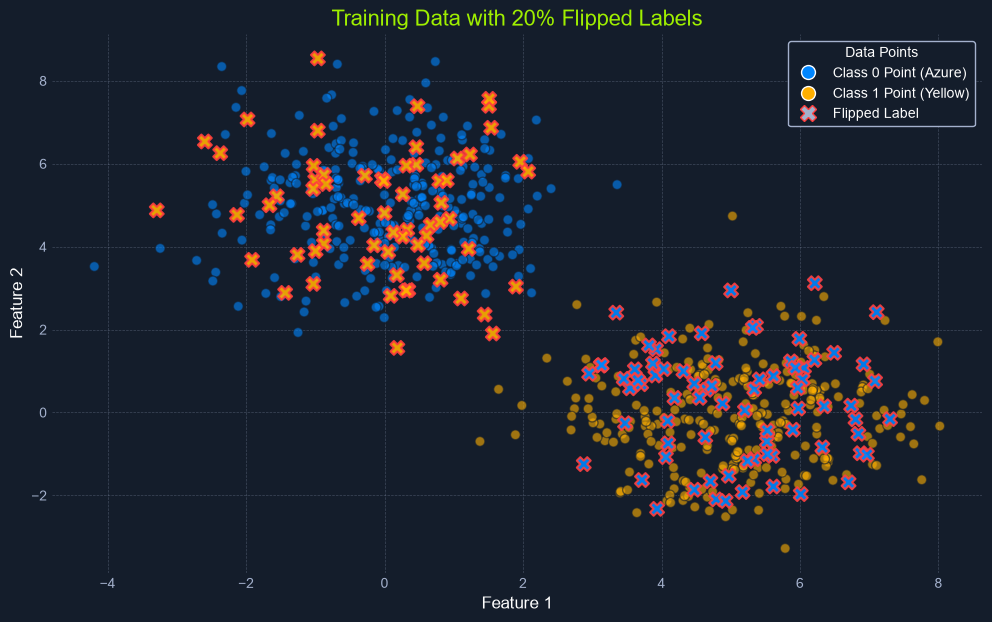

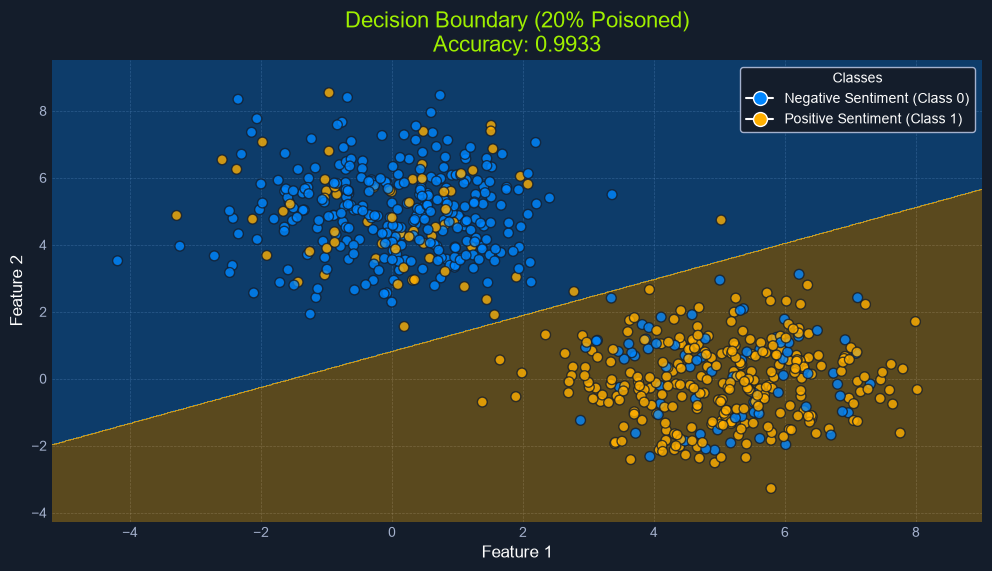


--- Training with 30% Poisoned Data ---
Flipping 210 labels (30.0%).
Accuracy on clean test set: 0.9933


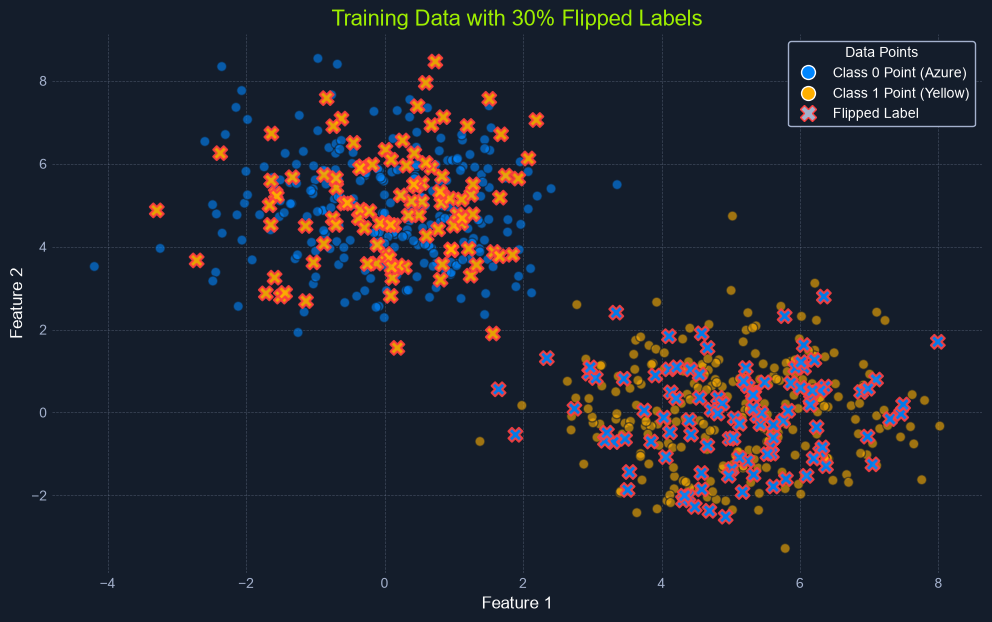

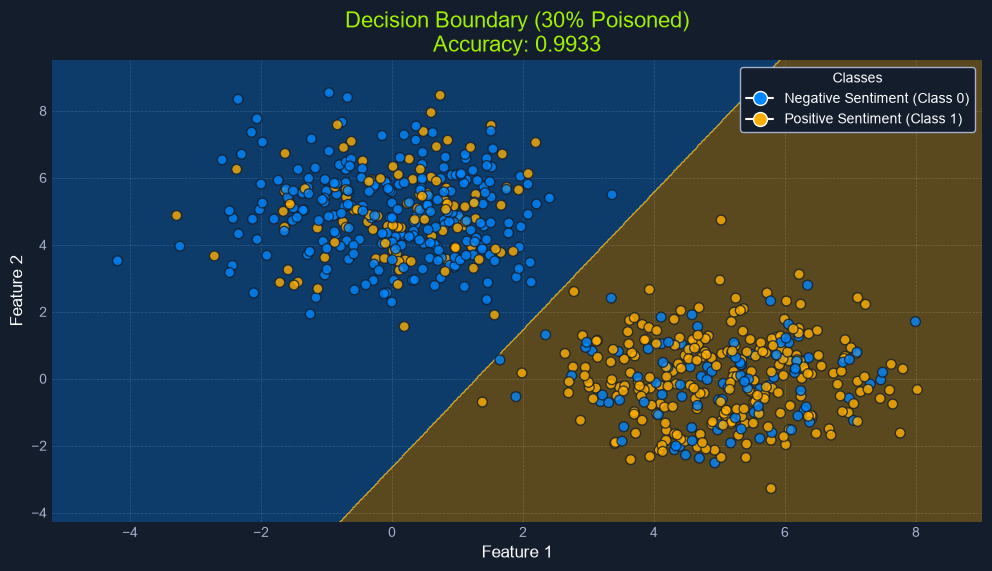


--- Training with 40% Poisoned Data ---
Flipping 280 labels (40.0%).
Accuracy on clean test set: 0.9933


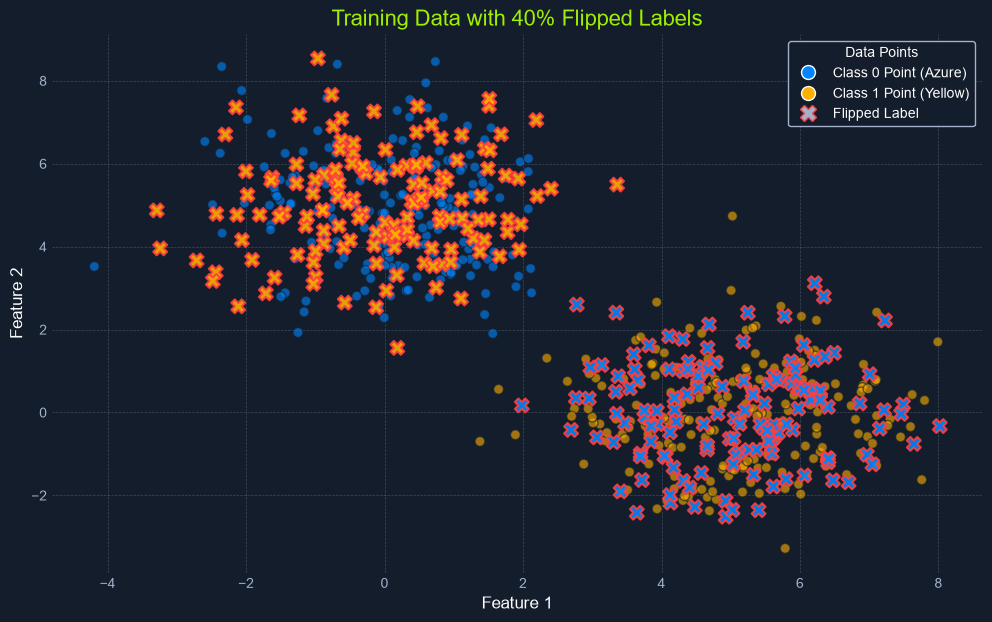

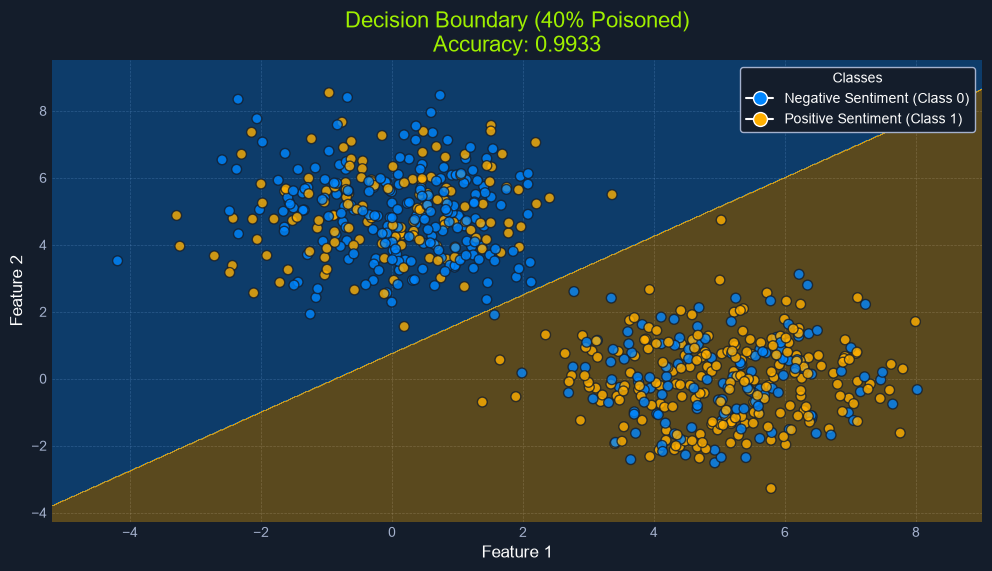


--- Training with 50% Poisoned Data ---
Flipping 350 labels (50.0%).
Accuracy on clean test set: 0.4767


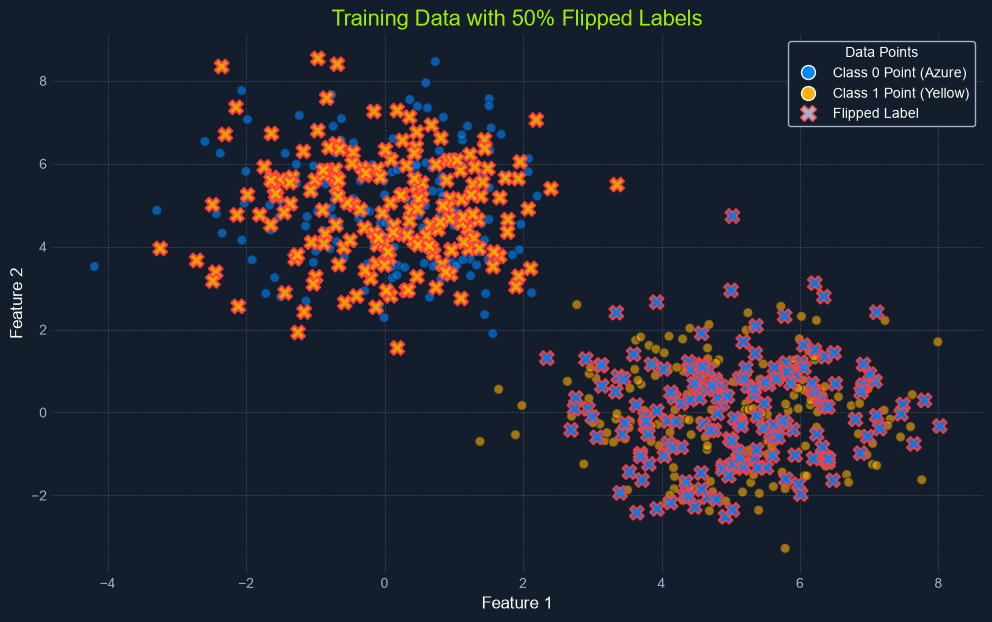

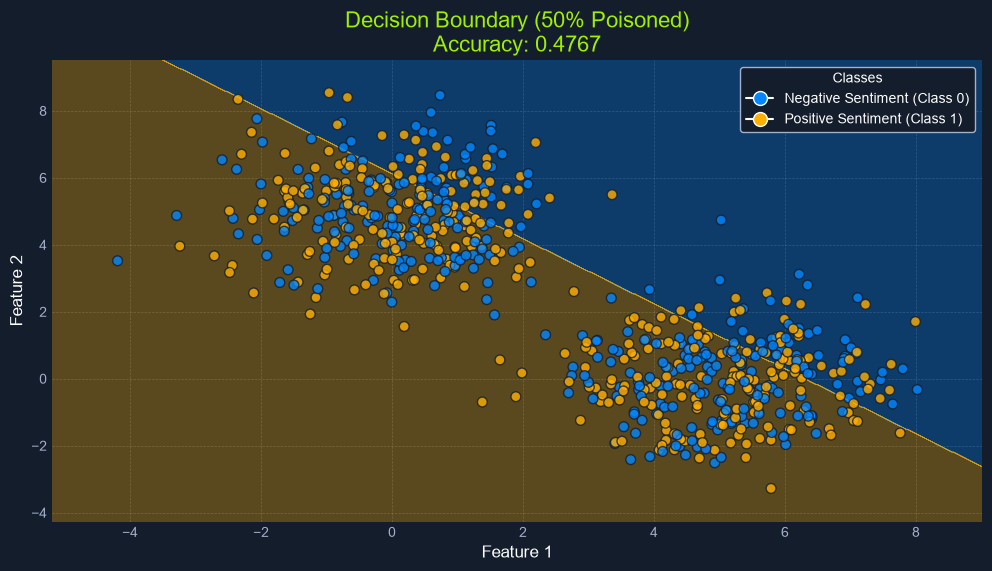


--- Evaluation Complete for Higher Percentages ---


In [9]:
poison_percentages_high = [0.20, 0.30, 0.40, 0.50]

for pp in poison_percentages_high:
    print(f"\n--- Training with {pp * 100:.0f}% Poisoned Data ---")

    # Create Poisoned Data
    y_train_poisoned, flipped_idx = flip_labels(y_train, pp)

    # Train Model on Poisoned Data
    poisoned_model = LogisticRegression(random_state=SEED)
    try:
        poisoned_model.fit(
            X_train, y_train_poisoned
        )  # Train with original X, but poisoned y
    except Exception as e:
        print(f"Error training model at {pp * 100}% poisoning: {e}")
        results["percentage"].append(pp)
        results["accuracy"].append(np.nan)  # Indicate failure
        results["model"].append(None)
        results["y_train_poisoned"].append(
            y_train_poisoned
        )  # Still store poisoned labels
        results["flipped_indices"].append(flipped_idx)  # and indices
        continue  # Skip to next percentage

    # Evaluate on Clean Test Data
    y_pred_poisoned = poisoned_model.predict(X_test)
    accuracy = accuracy_score(
        y_test, y_pred_poisoned
    )  # Always evaluate against TRUE test labels
    print(f"Accuracy on clean test set: {accuracy:.4f}")

    # Store Results
    results["percentage"].append(pp)
    results["accuracy"].append(accuracy)
    results["model"].append(poisoned_model)
    results["y_train_poisoned"].append(y_train_poisoned)
    results["flipped_indices"].append(flipped_idx)

    # Visualize Poisoned Data and Decision Boundary
    plot_poisoned_data(
        X_train,
        y_train,
        y_train_poisoned,
        flipped_idx,
        title=f"Training Data with {pp * 100:.0f}% Flipped Labels",
    )

    plot_decision_boundary(
        poisoned_model,
        X_train,
        y_train_poisoned,  # Visualize boundary with poisoned labels shown
        title=f"Decision Boundary ({pp * 100:.0f}% Poisoned)\nAccuracy: {accuracy:.4f}",
    )

    # Store decision boundary prediction for combined plot
    Z = poisoned_model.predict(mesh_points)
    Z = Z.reshape(xx.shape)
    decision_boundaries_data.append({"percentage": pp, "Z": Z})

print("\n--- Evaluation Complete for Higher Percentages ---")

#### Overall Plot Summary
We will now plot the clean-test accuracy of the model as a function of the percentage of flipped training labels (0 % to 50 %) to summarize the overall trend.

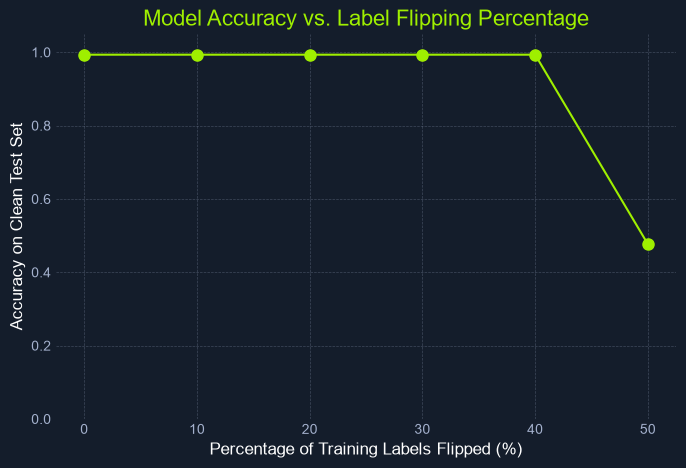

In [10]:
# Plot accuracy vs. poisoning percentage
plt.figure(figsize=(8, 5))
# Ensure percentages and accuracies are sorted correctly if the order changed for any reason
plot_data = sorted(zip(results["percentage"], results["accuracy"]))
plot_percentages = [p * 100 for p, a in plot_data]
plot_accuracies = [a for p, a in plot_data]

plt.plot(
    plot_percentages,
    plot_accuracies,
    marker="o",
    linestyle="-",
    color=htb_green,
    markersize=8,
)
plt.title("Model Accuracy vs. Label Flipping Percentage", fontsize=16, color=htb_green)
plt.xlabel("Percentage of Training Labels Flipped (%)", fontsize=12)
plt.ylabel("Accuracy on Clean Test Set", fontsize=12)
plt.xticks(plot_percentages)  # Ensure ticks match the evaluated percentages
plt.ylim(0, 1.05)
plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
plt.show()

#### Final Overlays
Even though accuracy stays high until 50 % poisoning, the decision boundary keeps shifting with every increase in flipped labels, so we will overlay all the boundaries in one plot to show this progressive movement. Here we can clearly see the decision boundary becoming increasingly distorted as the model attempted to accommodate the incorrect labels for each fraction of poisoned data.

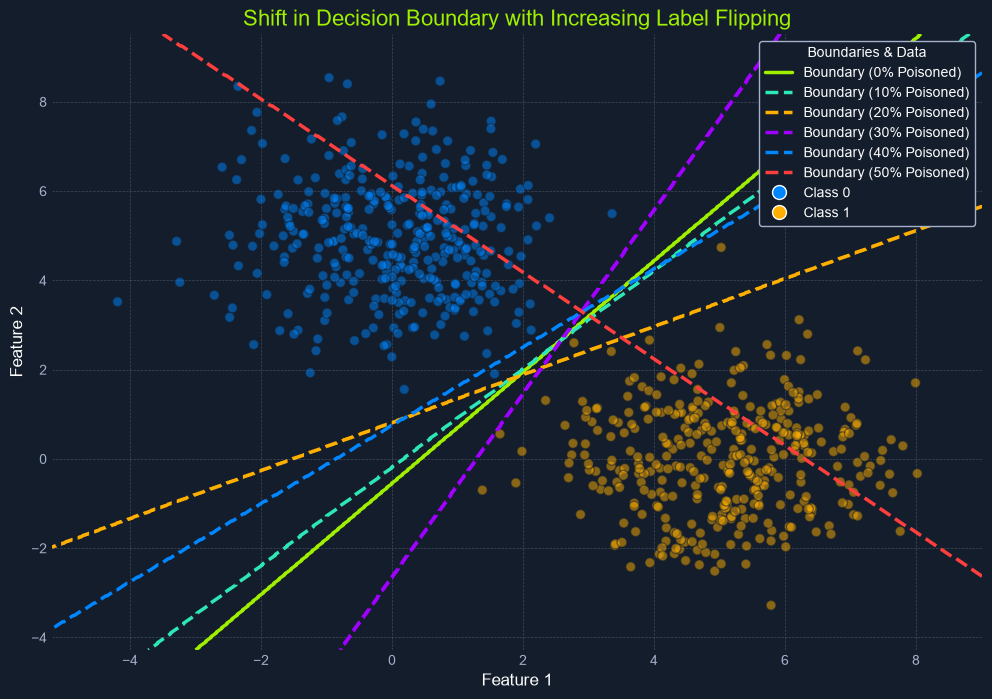

In [11]:
plt.figure(figsize=(12, 8))

# Plot the original clean data points for reference
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
    edgecolors=node_black,
    s=50,
    alpha=0.5,
    label="Clean Data Points",
)

contour_colors = {
    0.0: htb_green,
    0.10: aquamarine,
    0.20: nugget_yellow,
    0.30: vivid_purple,
    0.40: azure,
    0.50: malware_red,
}
contour_linestyles = {
    0.0: "solid",
    0.10: "dashed",
    0.20: "dashed",
    0.30: "dashed",
    0.40: "dashed",
    0.50: "dashed",
}

# Get baseline boundary data
baseline_model_idx = results["percentage"].index(0.0)
baseline_model_retrieved = results["model"][baseline_model_idx]
if baseline_model_retrieved:
    Z_baseline = baseline_model_retrieved.predict(mesh_points).reshape(xx.shape)
    cs = plt.contour(
        xx,
        yy,
        Z_baseline,
        levels=[0.5],
        colors=[contour_colors[0.0]],
        linestyles=[contour_linestyles[0.0]],
        linewidths=[2.5],
    )

boundary_indices_to_plot = [0.10, 0.20, 0.30, 0.40, 0.50]
plotted_percentages = [0.0]

# Sort decision_boundaries_data by percentage to ensure consistent plotting order
decision_boundaries_data.sort(key=lambda item: item["percentage"])

for data in decision_boundaries_data:
    pp = data["percentage"]
    if pp in boundary_indices_to_plot:
        if pp in contour_colors and pp in contour_linestyles:
            Z = data["Z"]
            cs = plt.contour(
                xx,
                yy,
                Z,
                levels=[0.5],
                colors=[contour_colors[pp]],
                linestyles=[contour_linestyles[pp]],
                linewidths=[2.5],
            )
            plotted_percentages.append(pp)
        else:
            print(f"Warning: Style not defined for {pp * 100}%, skipping contour.")


plt.title(
    "Shift in Decision Boundary with Increasing Label Flipping",
    fontsize=16,
    color=htb_green,
)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)

# Create legend
legend_handles = []
for pp in sorted(plotted_percentages):
    if (
        pp in contour_colors and pp in contour_linestyles
    ):  # Check again before creating legend entry
        legend_handles.append(
            plt.Line2D(
                [0],
                [0],
                color=contour_colors[pp],
                lw=2.5,
                linestyle=contour_linestyles[pp],
                label=f"Boundary ({pp * 100:.0f}% Poisoned)",
            )
        )

# Add legend for data points as well
data_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Class 0",
        markersize=10,
        markerfacecolor=azure,
        linestyle="None",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Class 1",
        markersize=10,
        markerfacecolor=nugget_yellow,
        linestyle="None",
    ),
]

plt.legend(handles=legend_handles + data_handles, title="Boundaries & Data")
plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()
